In [1]:
import json 
import pandas as pd 
import numpy as np 
import os 

RESULTS_DIR = "/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained"

def get_confidence_result(model='llava-v1.6-vicuna-7b-hf', dataset='vqa_1k_control'): 
    
    result = [] 
    filepath = f'{RESULTS_DIR}/{model}/{dataset}.jsonl' 
    if not os.path.exists(filepath): 
        print(filepath, 'does not exist')
        return 
    with open(filepath) as f:
        data_list = [json.loads(l) for l in f]
    
    if len(data_list) == 0: 
        os.remove(filepath)
        print(f'deleted', filepath )
        return 

    if len(data_list) < 1000:
        print(f'skip MODEL: {model} | DATASET: {dataset} | loaded {len(data_list)}')  
        return result
    else: 
       print(f'MODEL: {model} | DATASET: {dataset} | loaded {len(data_list)}')  
 
    for example in data_list:  
        output_answer_key = 'generated_answers' if 'generated_answers' in example.keys() else 'answers' 
        # dict_keys(['image_id', 'question', 'question_id', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated', 'image', 'answers', 'generated_logits'])
        if 'generated_logits' not in example.keys(): 
            print('generated_logits key does not exists, we only have:', example.keys(), example) 
            continue 
        for q in example['generated_logits'].keys():   
            logits = example['generated_logits'][q]['content']
            token_probs = np.exp([t['logprob'] for t in logits])
            confidence = token_probs.mean()  
            # print(f"{q}: {example[q]} \nAnswer: {example[output_answer_key][q]} conf: {confidence:.2f}")  
            result.append({
                'model': model, 
                'dataset': dataset, 
                'question_id': example['question_id'],
                'question': example[q], 
                'control_type': q, 
                'output': example[output_answer_key][q], 
                'confidence': round(confidence, 2)
            })
    return result  

In [2]:
models = os.listdir(RESULTS_DIR) # ["Qwen3-VL-8B-Instruct"]   # 'llava-v1.6-vicuna-7b-hf'] #  
datasets = ['vqa_1k_control', 'vqa_1k_control_inst_blind'] # 'vqa_1k', 'vqa_1k_inst_blind',  

df = []
for model in models: 
    for ds in datasets: 
        df.append(get_confidence_result(model, ds)) 
df = pd.DataFrame([item for sublist in df for item in (sublist if sublist else [])]) 
df.groupby(['model', 'dataset', 'control_type'])['output'].count()

skip MODEL: Qwen3-VL-32B-Instruct | DATASET: vqa_1k_control | loaded 43
skip MODEL: Qwen3-VL-32B-Instruct | DATASET: vqa_1k_control_inst_blind | loaded 974
MODEL: llava-v1.6-vicuna-7b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-v1.6-vicuna-7b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: llava-v1.6-vicuna-13b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-v1.6-vicuna-13b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: llava-1.5-7b-hf | DATASET: vqa_1k_control | loaded 1000
MODEL: llava-1.5-7b-hf | DATASET: vqa_1k_control_inst_blind | loaded 1000
MODEL: Qwen3-VL-4B-Instruct | DATASET: vqa_1k_control | loaded 1000
generated_logits key does not exists, we only have: dict_keys(['image_id', 'question', 'question_id', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated', 'image', 'answers']) {'image_id': 524577, 'question': 'What number of clocks are on this tower?', 'question_id': 524577006, 'deictic_removed': 'What number 

model                     dataset                    control_type   
Qwen3-VL-4B-Instruct      vqa_1k_control_inst_blind  deictic_removed    1000
                                                     object_removed     1000
                                                     question           1000
                                                     subject_ablated    1000
                                                     weaker_object      1000
Qwen3-VL-8B-Instruct      vqa_1k_control             deictic_removed    1000
                                                     object_removed     1000
                                                     question           1000
                                                     subject_ablated    1000
                                                     weaker_object      1000
llava-1.5-7b-hf           vqa_1k_control             deictic_removed    1000
                                                     object_removed     1000
       

In [3]:
df['confidence'] = df['confidence'].astype(str)
df.pivot_table(
    index=['model','question_id', 'control_type', ],
    columns=['dataset'],
    values=['question', 'output', 'confidence'],
    aggfunc=lambda x: ' | '.join(x)
).reindex(['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated'], level='control_type').dropna(axis=0) # .to_csv('./example_results_confidence.csv')

confidence  \
dataset                                             vqa_1k_control   
model                   question_id control_type                     
llava-1.5-7b-hf         589013      question                  0.77   
                                    deictic_removed           0.77   
                                    object_removed            0.77   
                                    weaker_object             0.77   
                                    subject_ablated           0.77   
...                                                            ...   
llava-v1.6-vicuna-7b-hf 580621000   question                  0.81   
                                    deictic_removed           0.81   
                                    object_removed            0.81   
                                    weaker_object             0.81   
                                    subject_ablated           0.86   

                                                                               \
dataset                                             vqa_1k_control_inst_blind   
model                   question_id control_type                                
llava-1.5-7b-hf         589013      question                             0.89   
                                    deictic_removed                      0.89   
                                    object_removed                       0.89   
                                    weaker_object                        0.89   
                                    subject_ablated                      0.89   
...                                                                       ...   
llava-v1.6-vicuna-7b-hf 580621000   question                              0.9   
                                    deictic_removed                      0.89   
                                    object_removed                       0.88   
                                    weaker_object                        0.88   
                                    subject_ablated                      0.87   

                                                            output  \
dataset                                             vqa_1k_control   
model                   question_id control_type                     
llava-1.5-7b-hf         589013      question                 Night   
                                    deictic_removed          Night   
                                    object_removed           Night   
                                    weaker_object            Night   
                                    subject_ablated          Night   
...                                                            ...   
llava-v1.6-vicuna-7b-hf 580621000   question                  Cafe   
                                    deictic_removed           Cafe   
                                    object_removed            Cafe   
                                    weaker_object             Cafe   
                                    subject_ablated     Restaurant   

                                                                               \
dataset                                             vqa_1k_control_inst_blind   
model                   question_id control_type                                
llava-1.5-7b-hf         589013      question                            Night   
                                    deictic_removed                     Night   
                                    object_removed                      Night   
                                    weaker_object                       Night   
                                    subject_ablated                     Night   
...                                                                       ...   
llava-v1.6-vicuna-7b-hf 580621000   question                       Restaurant   
                                    deictic_removed                Restaurant   
                                    object_removed                 R

In [4]:
control_type_order = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated']
table = df.pivot_table(
    index=['control_type'],
    columns=['dataset', 'model'],
    values=['confidence'],
    aggfunc=['mean', 'count']
) 
table = table.reindex(control_type_order)
table.round(3) 

TypeError: dtype 'str' does not support operation 'mean'

In [6]:
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

# Ensure confidence is numeric (earlier cell casts it to str for pivot)
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')

# Score each output against VQA ground-truth annotations
mapper = VQAAnswerMapper()

def score_row(row):
    gt_answers = mapper.get_answers(row['question_id'])
    if not gt_answers:
        return None
    return vqa_accuracy(row['output'], gt_answers)

df['accuracy'] = df.apply(score_row, axis=1)
print(f"Scored {df['accuracy'].notna().sum()} / {len(df)} rows")
df[['model', 'dataset', 'control_type', 'output', 'confidence', 'accuracy']].head(10)

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
Scored 50000 / 50000 rows


,model,dataset,control_type,output,confidence,accuracy
0,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,1,0.97,1.0
1,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,1,0.97,1.0
2,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,1,0.85,1.0
3,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,1,0.90,1.0
4,llava-v1.6-vicuna-7b-hf,vqa_1k_control,subject_ablated,12,0.78,0.0
5,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,On building,0.66,1.0
6,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,On building,0.66,1.0
7,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,Street,0.65,0.0
8,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,Wall,0.74,0.0
9,llava-v1.6-vicuna-7b-hf,vqa_1k_control,subject_ablated,Street,0.69,0.0


In [7]:
control_type_order = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'subject_ablated']

summary = (
    df.groupby(['model', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
summary['accuracy'] = (summary['accuracy'] * 100).round(1)
summary['confidence'] = (summary['confidence'] * 100).round(1)
summary['control_type'] = pd.Categorical(summary['control_type'], categories=control_type_order, ordered=True)
summary = summary.sort_values(['model', 'dataset', 'control_type'])

summary.pivot_table(
    index=['model', 'control_type'],
    columns='dataset',
    values=['accuracy', 'confidence'],
).round(1)


accuracy  \
dataset                                  vqa_1k_control   
model                    control_type                     
Qwen3-VL-4B-Instruct     question                   NaN   
                         deictic_removed            NaN   
                         object_removed             NaN   
                         weaker_object              NaN   
                         subject_ablated            NaN   
Qwen3-VL-8B-Instruct     question                  84.4   
                         deictic_removed           84.1   
                         object_removed            74.2   
                         weaker_object             78.2   
                         subject_ablated           72.1   
llava-1.5-7b-hf          question                  77.4   
                         deictic_removed           77.2   
                         object_removed            68.3   
                         weaker_object             72.0   
                         subject_ablated           66.1   
llava-v1.6-mistral-7b-hf question                  82.6   
                         deictic_removed           82.4   
                         object_removed            71.4   
                         weaker_object             76.7   
                         subject_ablated           69.0   
llava-v1.6-vicuna-13b-hf question                  82.9   
                         deictic_removed           82.4   
                         object_removed            71.6   
                         weaker_object             76.0   
                         subject_ablated           70.9   
llava-v1.6-vicuna-7b-hf  question                  82.6   
                         deictic_removed           82.4   
                         object_removed            72.2   
                         weaker_object             76.0   
                         subject_ablated           70.5   

                                                                    \
dataset                                  vqa_1k_control_inst_blind   
model                    control_type                                
Qwen3-VL-4B-Instruct     question                             37.1   
                         deictic_removed                      37.1   
                         object_removed                       31.8   
                         weaker_object                        32.8   
                         subject_ablated                      31.4   
Qwen3-VL-8B-Instruct     question                              NaN   
                         deictic_removed                       NaN   
                         object_removed                        NaN   
                         weaker_object                         NaN   
                         subject_ablated                       NaN   
llava-1.5-7b-hf          question                             34.0   
                         deictic_removed                      34.1   
                         object_removed                       32.9   
                         weaker_object                        33.4   
                         subject_ablated                      32.4   
llava-v1.6-mistral-7b-hf question                             36.4   
                         deictic_removed                      36.7   
                         object_removed                       33.7   
                         weaker_object                        33.6   
                         subject_ablated                      32.4   
llava-v1.6-vicuna-13b-hf question                             36.2   
                         deictic_removed                      36.2   
                         object_removed                       34.2   
                         weaker_object                        33.4   
                         subject_ablated                      32.6   
llava-v1.6-vicuna-7b-hf  question                             34.7   
                         deictic_removed                      34.7   

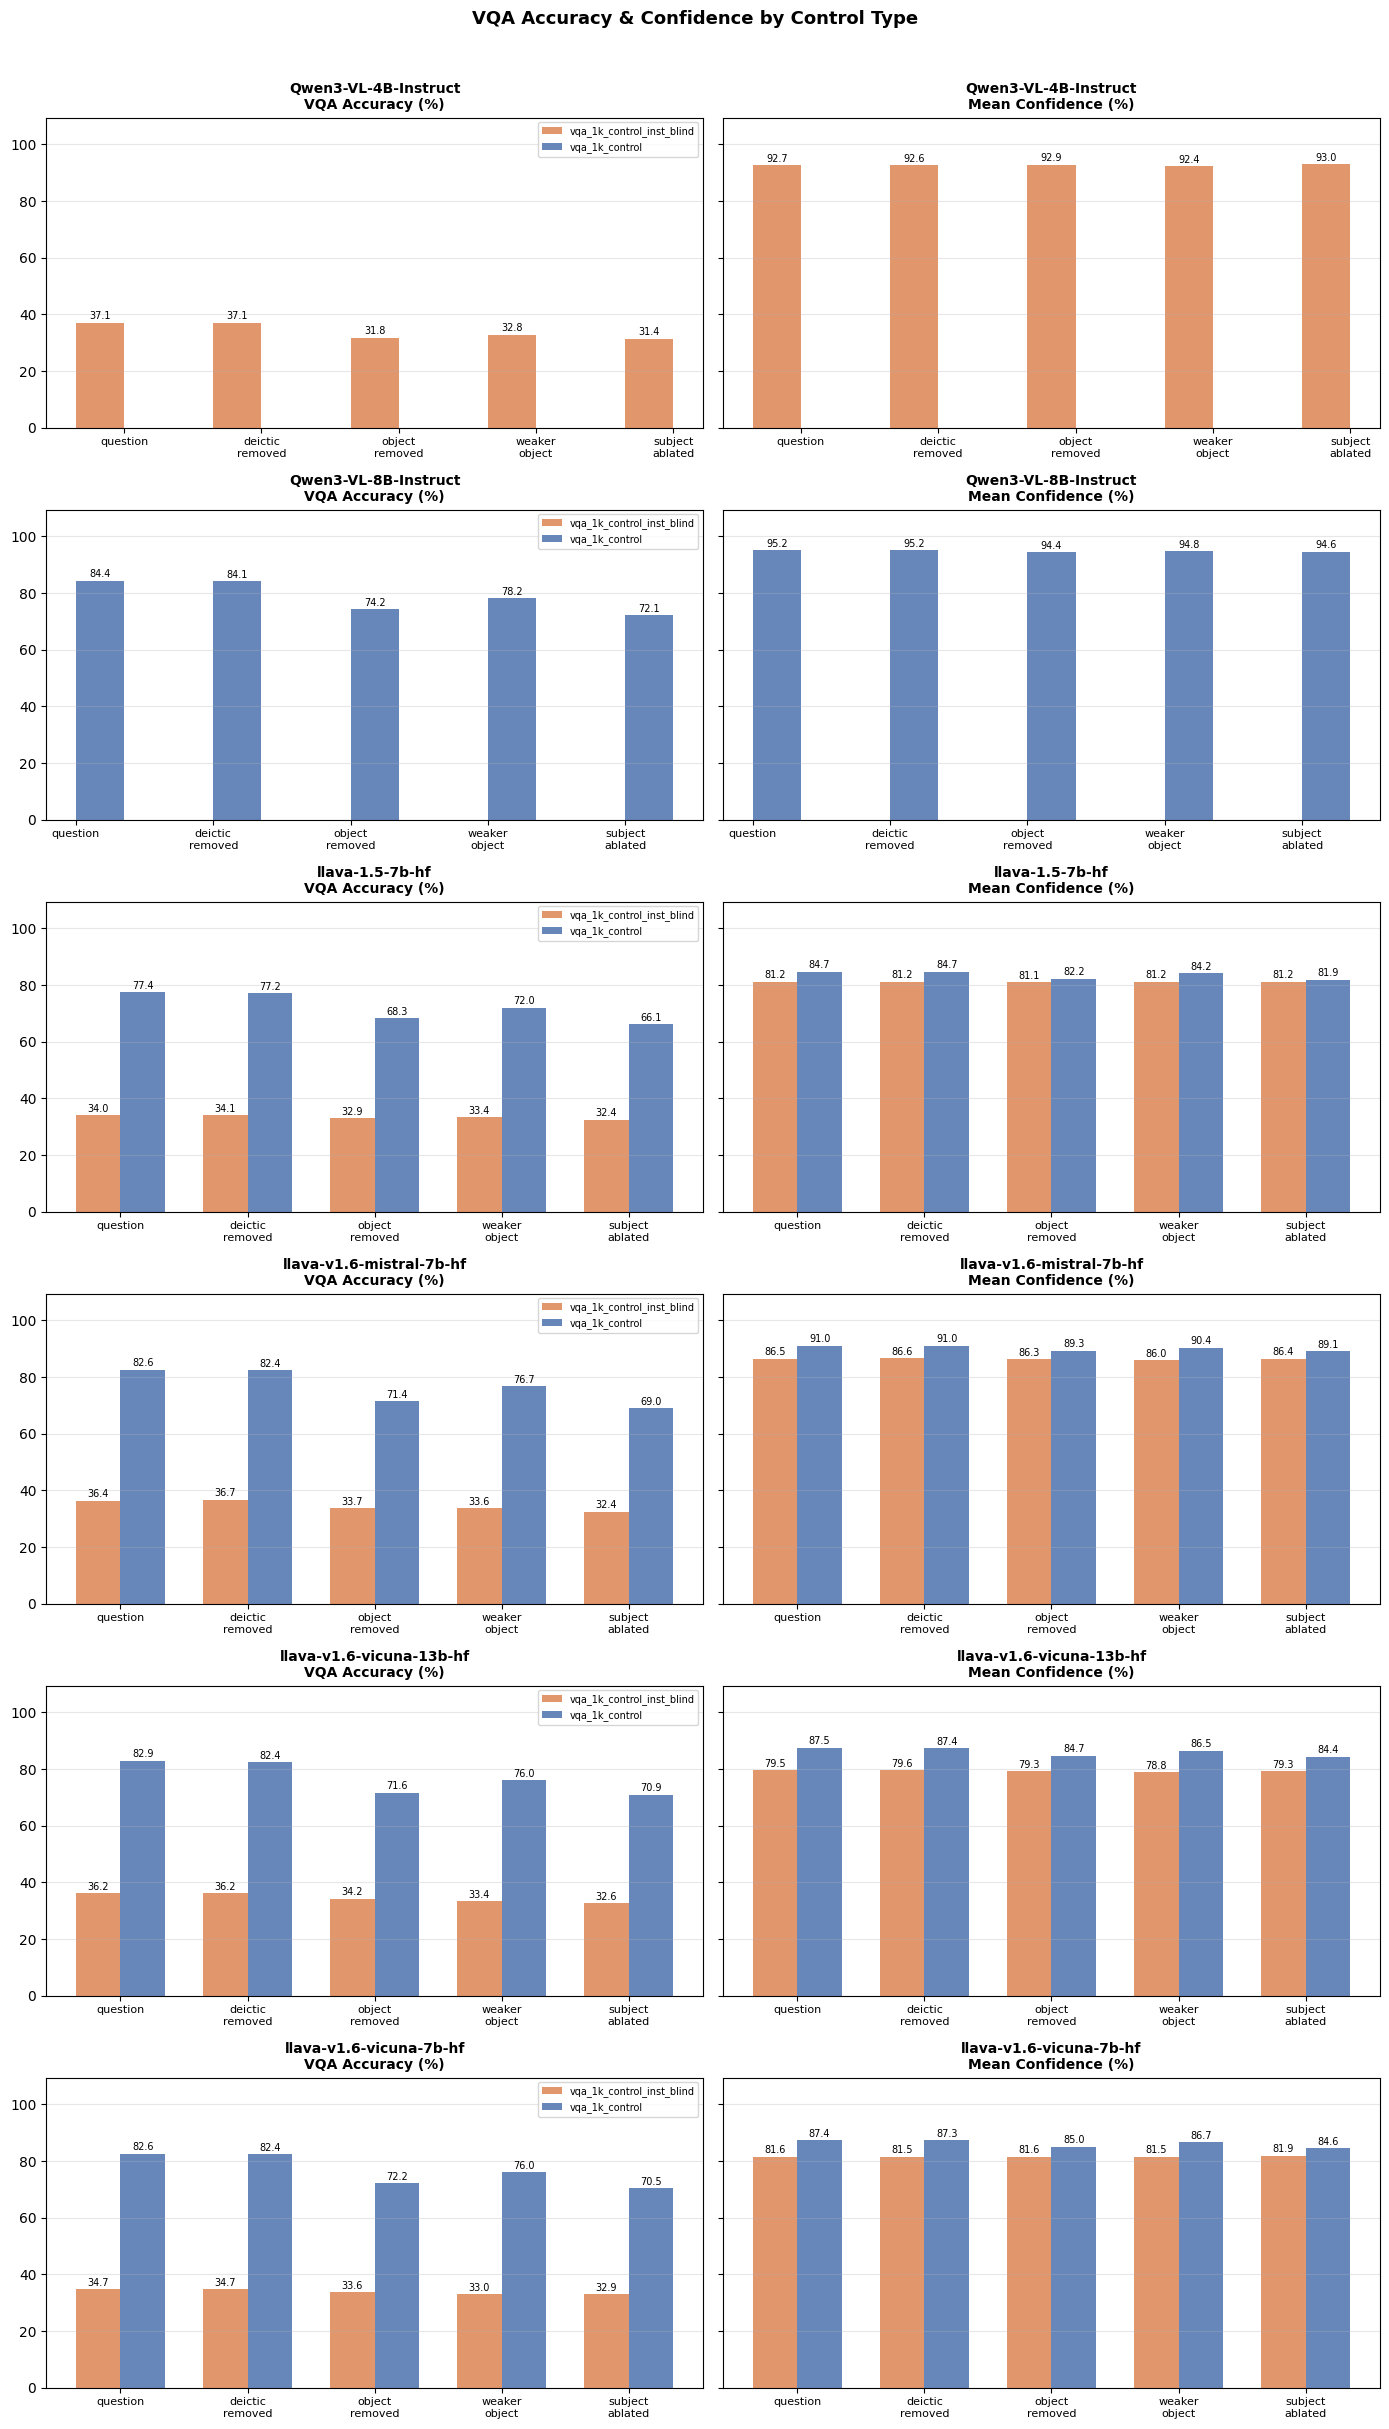

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

models = summary['model'].unique()
datasets = summary['dataset'].unique()
n_models = len(models)

fig, axes = plt.subplots(
    nrows=n_models, ncols=2,
    figsize=(14, 4 * n_models),
    sharey='row',
)
if n_models == 1:
    axes = [axes]

ct_labels = [c.replace('_', '\n') for c in control_type_order]
x = np.arange(len(control_type_order))
width = 0.35
ds_colors = {'vqa_1k_control': '#4C72B0', 'vqa_1k_control_inst_blind': '#DD8452'}

for row_i, model in enumerate(models):
    ax_acc, ax_conf = axes[row_i]

    for col_i, (ax, metric, title) in enumerate([
        (ax_acc, 'accuracy', 'VQA Accuracy (%)'),
        (ax_conf, 'confidence', 'Mean Confidence (%)'),
    ]):
        for ds_i, ds in enumerate(datasets):
            sub = summary[(summary['model'] == model) & (summary['dataset'] == ds)]
            sub = sub.set_index('control_type').reindex(control_type_order)
            vals = sub[metric].values
            offset = (ds_i - 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=ds, color=ds_colors.get(ds, None), alpha=0.85)
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                            f'{val:.1f}', ha='center', va='bottom', fontsize=7)

        ax.set_title(f'{model}\n{title}', fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        ax.set_ylim(0, max(summary[metric].max() * 1.15, 10))
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle('VQA Accuracy & Confidence by Control Type', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


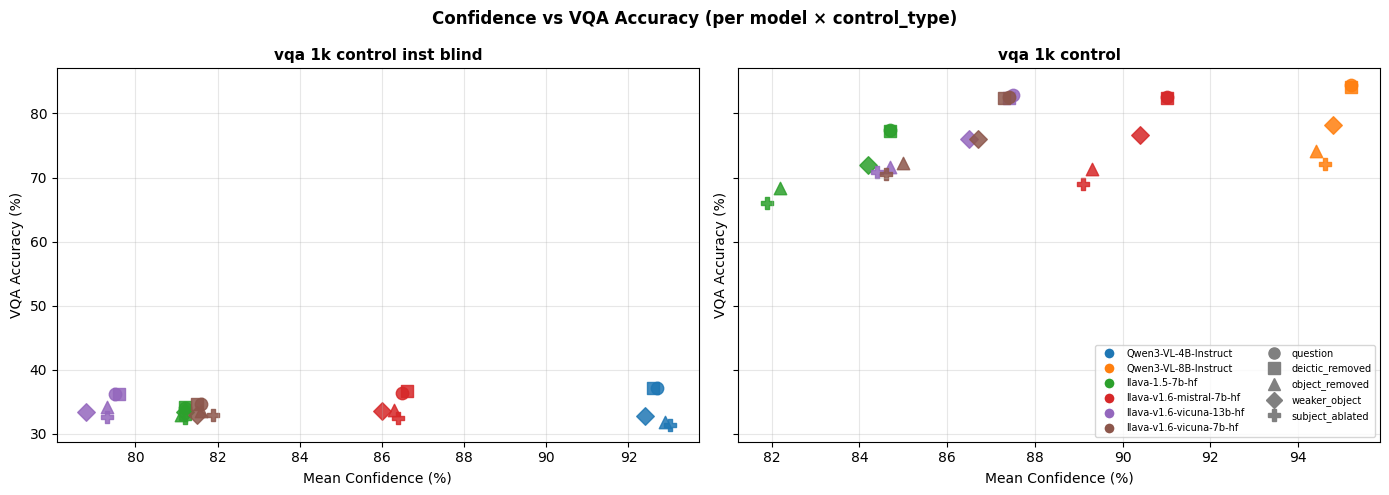

In [9]:
# Confidence vs Accuracy scatter — one point per (model, dataset, control_type)
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

markers = ['o', 's', '^', 'D', 'P']
ct_marker = {ct: markers[i % len(markers)] for i, ct in enumerate(control_type_order)}
model_colors = {m: plt.cm.tab10(i) for i, m in enumerate(models)}

for ax, ds in zip(axes, datasets):
    sub = summary[summary['dataset'] == ds]
    for model in models:
        for ct in control_type_order:
            row = sub[(sub['model'] == model) & (sub['control_type'] == ct)]
            if row.empty:
                continue
            ax.scatter(
                row['confidence'].values[0],
                row['accuracy'].values[0],
                color=model_colors[model],
                marker=ct_marker[ct],
                s=80, alpha=0.85,
                label=f'{model} / {ct}',
            )

    ax.set_xlabel('Mean Confidence (%)', fontsize=10)
    ax.set_ylabel('VQA Accuracy (%)', fontsize=10)
    ax.set_title(ds.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

# Shared legends: model (color) + control_type (shape)
color_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=model_colors[m], markersize=8, label=m) for m in models]
shape_handles = [plt.Line2D([0], [0], marker=ct_marker[ct], color='gray', markersize=8, linestyle='none', label=ct) for ct in control_type_order]
axes[-1].legend(handles=color_handles + shape_handles, fontsize=7, loc='lower right', ncol=2)

plt.suptitle('Confidence vs VQA Accuracy (per model × control_type)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
